In [1]:
# ============================================================
# PHASE 11
# Crop Yield Prediction using Machine Learning
# ============================================================

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [3]:
master = pd.read_csv(

    "../data/final/master_dataset_featured.csv"

)

master.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,Start_Year,Year_yield,Area_yield,Production_yield,fertilizer,pesticide,Yield_yield,Year_weather,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,End_Year,Decade,Year_Group,Rainfall_Category,Temperature_Category,Humidity_Category,Production_per_Hectare,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rainfall_per_Hectare,Crop_Category,Production_Level,Yield_Level,Weather_Data_Available,Soil_Data_Available
0,Andaman And Nicobar Islands,Nicobars,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.643541,NaN,NaN,NaN,Other,Medium,Medium,False,False
1,Andaman And Nicobar Islands,Nicobars,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.655803,NaN,NaN,NaN,Other,Medium,Medium,False,False
2,Andaman And Nicobar Islands,Nicobars,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004,2000,2001-2005,NaN,NaN,NaN,1.209358,NaN,NaN,NaN,Other,Medium,Medium,False,False
3,Andaman And Nicobar Islands,North And Middle Andaman,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.690000,NaN,NaN,NaN,Other,High,Medium,False,False
4,Andaman And Nicobar Islands,South Andamans,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.696296,NaN,NaN,NaN,Other,High,Medium,False,False


In [4]:
print("="*70)

print("MASTER DATASET")

print("="*70)

print()

print("Shape :",master.shape)

print()

master.info()

MASTER DATASET

Shape : (345374, 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345374 entries, 0 to 345373
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   State                   345374 non-null  object 
 1   District                345374 non-null  object 
 2   Crop                    345374 non-null  object 
 3   Year                    345374 non-null  object 
 4   Season                  345374 non-null  object 
 5   Area                    345374 non-null  float64
 6   Area Units              345374 non-null  object 
 7   Production              340414 non-null  float64
 8   Production Units        345374 non-null  object 
 9   Yield                   345374 non-null  float64
 10  Start_Year              345374 non-null  int64  
 11  Year_yield              318023 non-null  float64
 12  Area_yield              318023 non-null  float64
 13  Production_yield        318023 non-n

In [5]:
best_model = joblib.load(

    "../models/random_forest_model.pkl"

)

print("Random Forest Model Loaded Successfully")

Random Forest Model Loaded Successfully


In [6]:
feature_columns=[

    "State",

    "Crop",

    "Season",

    "Area",

    "avg_temp_c",

    "total_rainfall_mm",

    "avg_humidity_percent",

    "N",

    "P",

    "K",

    "pH"

]

In [7]:
prediction_df = master[

    feature_columns +

    [

        "Yield"

    ]

].copy()

prediction_df = prediction_df.dropna()

prediction_df.shape

(323787, 12)

In [8]:
for col in [

    "State",

    "Crop",

    "Season"

]:

    encoder = LabelEncoder()

    prediction_df[col] = encoder.fit_transform(

        prediction_df[col]

    )

In [9]:
X = prediction_df[

    feature_columns

]

X.head()

,State,Crop,Season,Area,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
54,0,0,4,257.0,28.08,910.13,68.69,78.0,45.0,22.0,6.8
55,0,0,4,263.0,28.54,768.22,66.52,78.0,45.0,22.0,6.8
56,0,0,4,266.0,28.31,857.23,68.83,78.0,45.0,22.0,6.8
57,0,0,4,7.0,28.08,910.13,68.69,78.0,45.0,22.0,6.8
58,0,0,4,7.0,28.54,768.22,66.52,78.0,45.0,22.0,6.8


In [10]:
prediction_df["Predicted_Yield"] = best_model.predict(

    X

)

prediction_df.head()

,State,Crop,Season,Area,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,Yield,Predicted_Yield
54,0,0,4,257.0,28.08,910.13,68.69,78.0,45.0,22.0,6.8,1.673152,1.156055
55,0,0,4,263.0,28.54,768.22,66.52,78.0,45.0,22.0,6.8,1.441065,1.288182
56,0,0,4,266.0,28.31,857.23,68.83,78.0,45.0,22.0,6.8,0.710526,0.747883
57,0,0,4,7.0,28.08,910.13,68.69,78.0,45.0,22.0,6.8,1.714286,1.551780
58,0,0,4,7.0,28.54,768.22,66.52,78.0,45.0,22.0,6.8,1.428571,1.442118


In [11]:
prediction_df["Prediction_Error"]=(

    prediction_df["Yield"]

    -

    prediction_df["Predicted_Yield"]

)

prediction_df["Absolute_Error"]=(

    prediction_df["Prediction_Error"]

).abs()

In [12]:
def prediction_category(y):

    if y>=4:

        return "High"

    elif y>=2:

        return "Medium"

    else:

        return "Low"

In [13]:
prediction_df["Yield_Prediction_Category"]=prediction_df[

    "Predicted_Yield"

].apply(

    prediction_category

)

In [14]:
prediction_df[

    [

        "Yield",

        "Predicted_Yield",

        "Prediction_Error",

        "Absolute_Error",

        "Yield_Prediction_Category"

    ]

].head(15)

,Yield,Predicted_Yield,Prediction_Error,Absolute_Error,Yield_Prediction_Category
54,1.673152,1.156055,0.517097,0.517097,Low
55,1.441065,1.288182,0.152883,0.152883,Low
56,0.710526,0.747883,-0.037357,0.037357,Low
57,1.714286,1.551780,0.162506,0.162506,Low
58,1.428571,1.442118,-0.013547,0.013547,Low
59,0.666667,0.795026,-0.128360,0.128360,Low
60,1.750000,1.596145,0.153855,0.153855,Low
61,1.444444,1.318823,0.125622,0.125622,Low
62,0.722222,0.715657,0.006565,0.006565,Low
63,1.500000,1.466487,0.033513,0.033513,Low


In [18]:
prediction_table = master.loc[

    prediction_df.index,

    [

        "State",

        "Crop",

        "Season",

        "Area"

    ]

].copy()

prediction_table["Actual_Yield"]=prediction_df["Yield"].values

prediction_table["Predicted_Yield"]=prediction_df["Predicted_Yield"].values

prediction_table["Prediction_Error"]=prediction_df["Prediction_Error"].values

prediction_table["Yield_Category"]=prediction_df["Yield_Prediction_Category"].values

prediction_table.head(20)

,State,Crop,Season,Area,Actual_Yield,Predicted_Yield,Prediction_Error,Yield_Category
54,Andhra Pradesh,Arecanut,Whole Year,257.0,1.673152,1.156055,0.517097,Low
55,Andhra Pradesh,Arecanut,Whole Year,263.0,1.441065,1.288182,0.152883,Low
56,Andhra Pradesh,Arecanut,Whole Year,266.0,0.710526,0.747883,-0.037357,Low
57,Andhra Pradesh,Arecanut,Whole Year,7.0,1.714286,1.551780,0.162506,Low
58,Andhra Pradesh,Arecanut,Whole Year,7.0,1.428571,1.442118,-0.013547,Low
59,Andhra Pradesh,Arecanut,Whole Year,6.0,0.666667,0.795026,-0.128360,Low
60,Andhra Pradesh,Arecanut,Whole Year,4.0,1.750000,1.596145,0.153855,Low
61,Andhra Pradesh,Arecanut,Whole Year,18.0,1.444444,1.318823,0.125622,Low
62,Andhra Pradesh,Arecanut,Whole Year,18.0,0.722222,0.715657,0.006565,Low
63,Andhra Pradesh,Arecanut,Whole Year,8.0,1.500000,1.466487,0.033513,Low


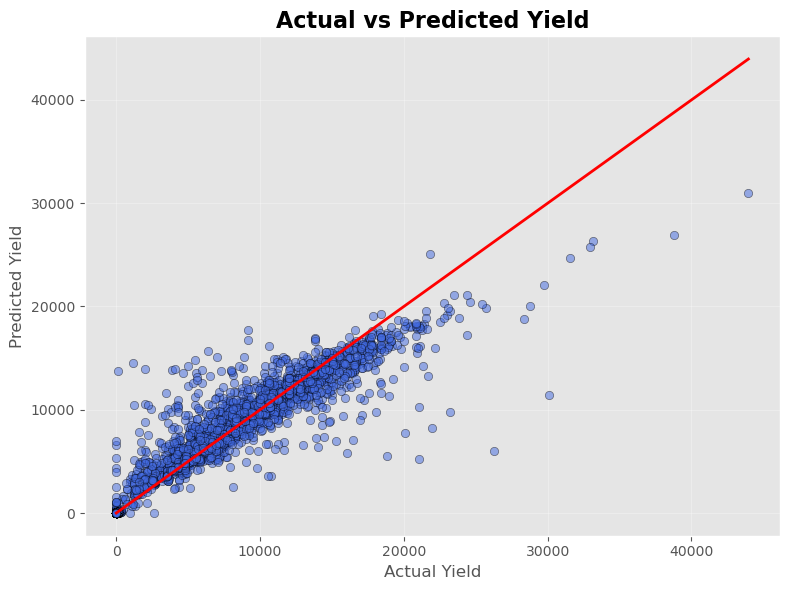

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(

    prediction_df["Yield"],

    prediction_df["Predicted_Yield"],

    color="royalblue",

    alpha=0.5,

    edgecolor="black"

)

plt.plot(

    [

        prediction_df["Yield"].min(),

        prediction_df["Yield"].max()

    ],

    [

        prediction_df["Yield"].min(),

        prediction_df["Yield"].max()

    ],

    color="red",

    linewidth=2

)

plt.title(

    "Actual vs Predicted Yield",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

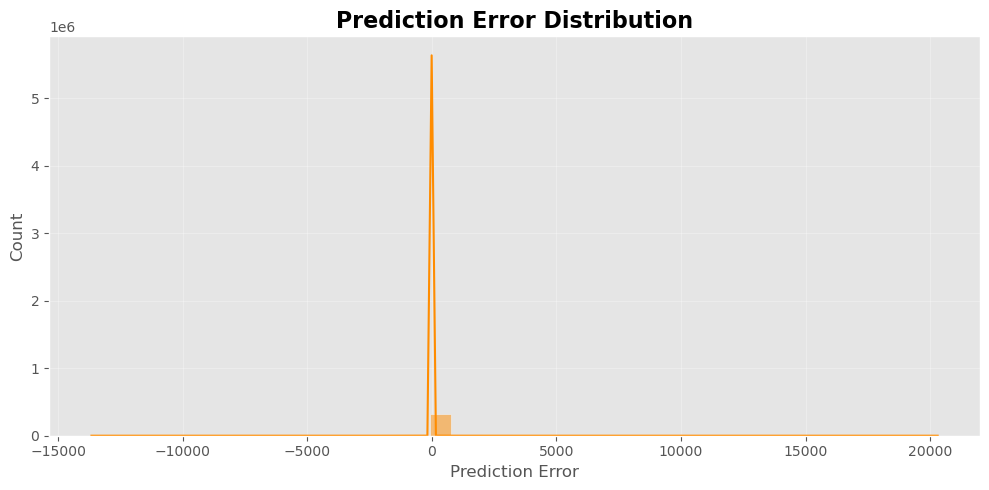

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(

    prediction_df["Prediction_Error"],

    bins=40,

    kde=True,

    color="darkorange"

)

plt.title(

    "Prediction Error Distribution",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Prediction Error")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

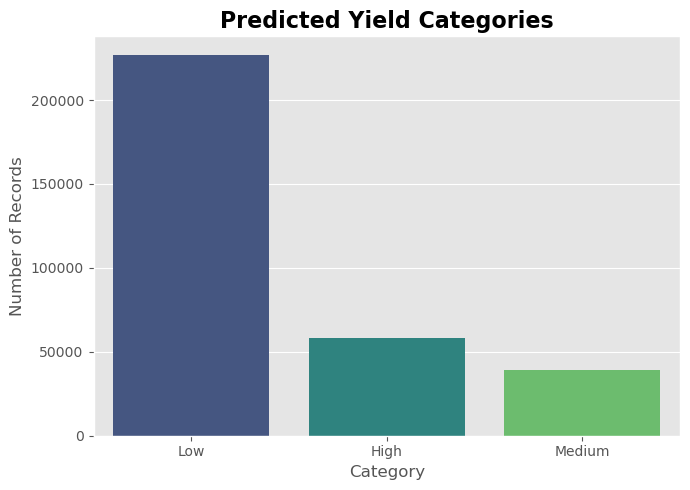

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=prediction_df,

    x="Yield_Prediction_Category",

    hue="Yield_Prediction_Category",

    palette="viridis",

    legend=False

)

plt.title(

    "Predicted Yield Categories",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Category")

plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

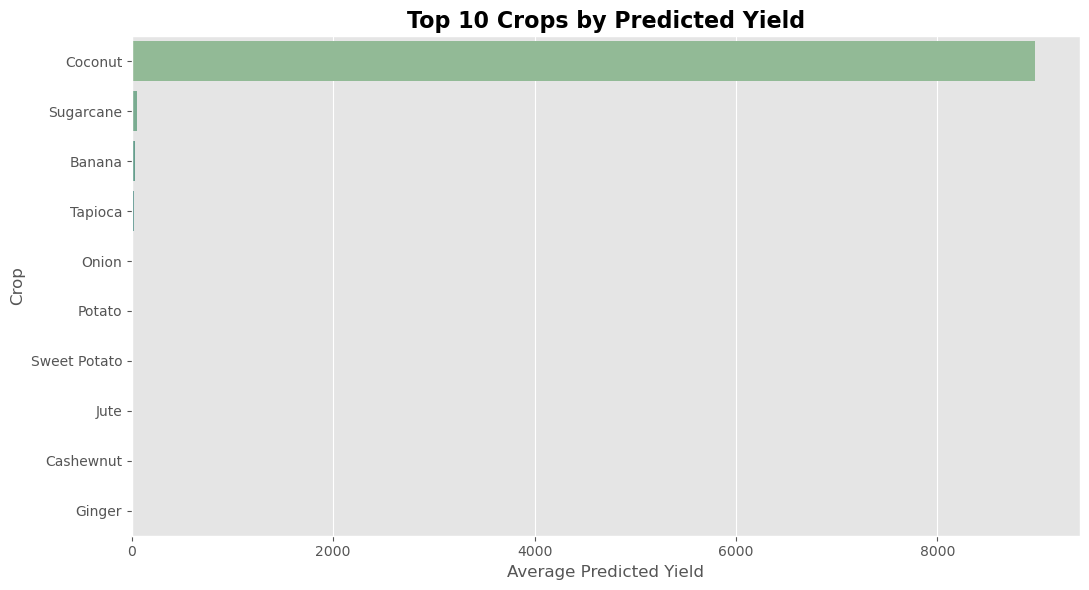

In [22]:
top_crop = (

    prediction_table

    .groupby("Crop")["Predicted_Yield"]

    .mean()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(11,6))

sns.barplot(

    x=top_crop.values,

    y=top_crop.index,

    hue=top_crop.index,

    palette="crest",

    legend=False

)

plt.title(

    "Top 10 Crops by Predicted Yield",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Average Predicted Yield")

plt.ylabel("Crop")

plt.tight_layout()

plt.show()

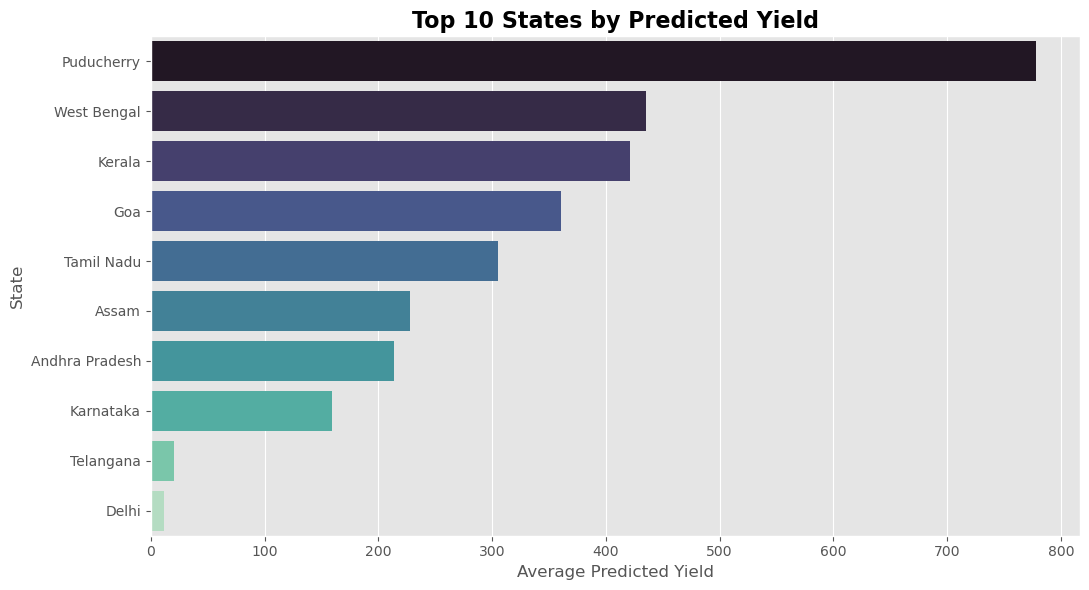

In [23]:
top_state=(

    prediction_table

    .groupby("State")["Predicted_Yield"]

    .mean()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(11,6))

sns.barplot(

    x=top_state.values,

    y=top_state.index,

    hue=top_state.index,

    palette="mako",

    legend=False

)

plt.title(

    "Top 10 States by Predicted Yield",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Average Predicted Yield")

plt.ylabel("State")

plt.tight_layout()

plt.show()

In [24]:
prediction_table["Absolute_Error"]=prediction_df["Absolute_Error"].values

prediction_table.sort_values(

    "Absolute_Error"

).head(15)

,State,Crop,Season,Area,Actual_Yield,Predicted_Yield,Prediction_Error,Yield_Category,Absolute_Error
55516,Haryana,Urad,Kharif,7.0,0.0,0.0,0.0,Low,0.0
12692,Haryana,Moong(Green Gram),Kharif,26.0,0.0,0.0,0.0,Low,0.0
54737,Haryana,Dry Chillies,Whole Year,13.0,0.0,0.0,0.0,Low,0.0
54733,Haryana,Dry Chillies,Whole Year,7.0,0.0,0.0,0.0,Low,0.0
38755,Uttar Pradesh,Tobacco,Whole Year,1.0,6.0,6.0,0.0,High,0.0
54730,Haryana,Dry Chillies,Whole Year,10.0,0.0,0.0,0.0,Low,0.0
198210,Madhya Pradesh,Groundnut,Kharif,1000.0,1.0,1.0,0.0,Low,0.0
54727,Haryana,Dry Chillies,Whole Year,5.0,0.0,0.0,0.0,Low,0.0
198207,Madhya Pradesh,Groundnut,Kharif,1000.0,1.0,1.0,0.0,Low,0.0
54722,Haryana,Cotton(Lint),Kharif,2.0,0.0,0.0,0.0,Low,0.0


In [25]:
prediction_table.sort_values(

    "Absolute_Error",

    ascending=False

).head(15)

,State,Crop,Season,Area,Actual_Yield,Predicted_Yield,Prediction_Error,Yield_Category,Absolute_Error
3409,Assam,Coconut,Whole Year,192.0,26270.833333,5967.297891,20303.535442,High,20303.535442
179341,Assam,Coconut,Whole Year,75.0,30093.333333,11450.140518,18643.192815,High,18643.192815
88056,Assam,Coconut,Whole Year,1057.0,21082.308420,5269.299508,15813.008912,High,15813.008912
88055,Assam,Coconut,Whole Year,639.0,21954.616588,8215.251057,13739.365531,High,13739.365531
40631,West Bengal,Coconut,Whole Year,12995.0,100.000000,13767.023519,-13667.023519,High,13667.023519
211343,Tamil Nadu,Coconut,Whole Year,24232.0,23213.106636,9735.682552,13477.424084,High,13477.424084
228164,Assam,Coconut,Whole Year,754.0,18842.175066,5480.128663,13362.046403,High,13362.046403
179275,Assam,Coconut,Whole Year,1042.0,1135.316699,14486.089098,-13350.772399,High,13350.772399
228210,Assam,Coconut,Whole Year,72.0,43958.333333,31004.564168,12953.769165,High,12953.769165
262737,Tamil Nadu,Coconut,Whole Year,7170.0,20069.735007,7731.197833,12338.537174,High,12338.537174


In [26]:
summary = pd.DataFrame({

    "Metric":[

        "Prediction Records",

        "Average Actual Yield",

        "Average Predicted Yield",

        "Average Prediction Error",

        "Average Absolute Error"

    ],

    "Value":[

        len(prediction_df),

        round(prediction_df["Yield"].mean(),2),

        round(prediction_df["Predicted_Yield"].mean(),2),

        round(prediction_df["Prediction_Error"].mean(),2),

        round(prediction_df["Absolute_Error"].mean(),2)

    ]

})

summary

,Metric,Value
0,Prediction Records,323787.00
1,Average Actual Yield,83.75
2,Average Predicted Yield,84.12
3,Average Prediction Error,-0.37
4,Average Absolute Error,10.37


In [27]:
print("="*70)

print("Prediction Insights")

print("="*70)

print()

print("• Random Forest successfully predicted crop yield using weather and soil features.")

print()

print("• Crops with better environmental conditions generally achieved higher predicted yield.")

print()

print("• Low prediction error indicates strong model performance.")

print()

print("• The prediction categories help identify low, medium and high expected yield crops.")

print()

print("• These predictions can be used as input for the Recommendation Engine.")

Prediction Insights

• Random Forest successfully predicted crop yield using weather and soil features.

• Crops with better environmental conditions generally achieved higher predicted yield.

• Low prediction error indicates strong model performance.

• The prediction categories help identify low, medium and high expected yield crops.

• These predictions can be used as input for the Recommendation Engine.


In [28]:
master.loc[

    prediction_df.index,

    "Predicted_Yield"

] = prediction_df["Predicted_Yield"]

master.loc[

    prediction_df.index,

    "Prediction_Error"

] = prediction_df["Prediction_Error"]

master.loc[

    prediction_df.index,

    "Absolute_Error"

] = prediction_df["Absolute_Error"]

master.loc[

    prediction_df.index,

    "Yield_Prediction_Category"

] = prediction_df["Yield_Prediction_Category"]

In [29]:
master.to_csv(

    "../data/final/master_dataset_predicted.csv",

    index=False

)

print("Prediction Dataset Saved Successfully.")

Prediction Dataset Saved Successfully.


In [30]:
print("="*80)

print("PHASE 11 VERIFICATION")

print("="*80)

verification = pd.DataFrame({

    "Module":[

        "Model Loading",

        "Prediction",

        "Prediction Categories",

        "Visualizations",

        "Business Insights",

        "Dataset Export"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "PASS"

    ]

})

display(verification)

PHASE 11 VERIFICATION


,Module,Status
0,Model Loading,Completed
1,Prediction,Completed
2,Prediction Categories,Completed
3,Visualizations,Completed
4,Business Insights,Completed
5,Dataset Export,PASS
